# Train Synthetic, Test Real Evaluation


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

from core.data import load_dataset, split_dataset, BreathDataset
from models.vae import VAE, CVAE
from models.gan import CGAN

plt.rcParams.update({'legend.fontsize': 9,
                     'axes.titlesize': 10})

In [2]:
# paths and params
RESULT_DIR = 'results'
SEEDS = [0, 1,7, 42, 123]
REGIONS = ['mouth', 'nose']
REGION_STYLE = {'mouth': '-', 'nose': '--'}
CLASSES = ['bradypnea', 'eupnea', 'tachypnea']
CLASS_COLORS = {'bradypnea': 'tab:blue', 'eupnea': 'tab:green', 'tachypnea': 'tab:purple'}
MODELS = ['trtr', 'cvae', 'vae', 'gan']
MODEL_COLOR = {'trtr': 'tab:blue', 'cvae': 'tab:green', 'vae': 'tab:orange', 'gan': 'tab:red'}
CHANNEL_NAMES = ['Humidity in %', 'Temperature in °C']
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')

## Summary

We begin with a summary of downstream classification accuracy across all generative models, evaluated under the Train on Synthetic, Test on Real (TSTR) protocol. The TRTR baseline (trained and tested on real data) provides the performance ceiling. A random classifier on three balanced classes achieves 0.333.

The results reveal a clear hierarchy: TRTR (0.952 mouth) > CVAE (0.793) > GAN (0.464) ≈ VAE (0.471), with all models degrading on nose signals. The VAE and GAN operate near chance level, indicating that unconditional generation fails to produce class-informative samples. The CVAE closes most of the gap to TRTR, motivating a closer diagnostic examination of why the unconditional VAE fails.

model region      accuracy   f1_weighted   roc_auc_ovr      log_loss  f1_bradypnea     f1_eupnea  f1_tachypnea feature_overlap
 trtr  mouth 0.936 ± 0.039 0.935 ± 0.039 0.992 ± 0.015 0.213 ± 0.069 0.955 ± 0.062 0.924 ± 0.060 0.928 ± 0.060             nan
 cvae  mouth 0.793 ± 0.130 0.793 ± 0.130 0.920 ± 0.046 0.582 ± 0.228 0.798 ± 0.126 0.763 ± 0.161 0.815 ± 0.145   0.400 ± 0.122
  vae  mouth 0.471 ± 0.244 0.466 ± 0.245 0.639 ± 0.248 1.063 ± 0.097 0.533 ± 0.258 0.393 ± 0.246 0.470 ± 0.273   0.540 ± 0.089
  gan  mouth 0.429 ± 0.113 0.386 ± 0.092 0.623 ± 0.081 1.189 ± 0.174 0.538 ± 0.143 0.356 ± 0.270 0.276 ± 0.292   0.500 ± 0.071
 trtr   nose 0.800 ± 0.048 0.796 ± 0.049 0.933 ± 0.022 0.484 ± 0.068 0.900 ± 0.055 0.778 ± 0.049 0.703 ± 0.104             nan
 cvae   nose 0.579 ± 0.042 0.570 ± 0.040 0.757 ± 0.039 0.953 ± 0.072 0.640 ± 0.077 0.487 ± 0.032 0.582 ± 0.071   0.400 ± 0.141
  vae   nose 0.337 ± 0.120 0.311 ± 0.099 0.499 ± 0.132 1.120 ± 0.057 0.280 ± 0.176 0.306 ± 0.127 0.349 ± 0.265 

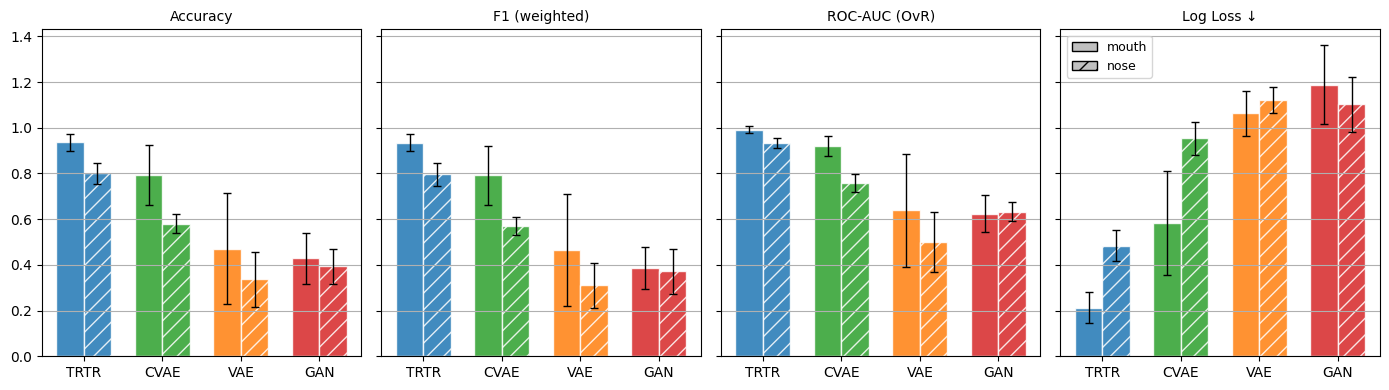

In [3]:
# load summary
df = pd.read_csv(f'{RESULT_DIR}/summary.csv')
df = df[df['free_bits'].isna() | (df['free_bits'] == 0.0)] # only include vanilla models, i.e. no free_bits
df['model'] = pd.Categorical(df['model'], categories=MODELS, ordered=True)
df = df.sort_values(['region', 'model', 'seed']).reset_index(drop=True)

# print summary
metrics_cols = ['accuracy', 'f1_weighted', 'roc_auc_ovr', 'log_loss', 'f1_bradypnea', 'f1_eupnea', 'f1_tachypnea', 'feature_overlap']
agg = df.groupby(['model', 'region'], observed=True)[metrics_cols].agg(['mean', 'std']).round(3)
rows = []
for (model, region), g in df.groupby(['model', 'region'], observed=True):
    row = {'model': model, 'region': region}
    for m in metrics_cols:
        mu = g[m].mean()
        sd = g[m].std()
        if pd.isna(sd) or len(g) < 2:
            row[m] = f'{mu:.3f}'
        else:
            row[m] = f'{mu:.3f} ± {sd:.3f}'
    rows.append(row)
summary = pd.DataFrame(rows)
summary['model'] = pd.Categorical(summary['model'], categories=MODELS, ordered=True)
summary = summary.sort_values(['region', 'model']).reset_index(drop=True)
print(summary.to_string(index=False))

# plot summary
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
axes = axes.flatten()
metrics_abs = ['accuracy', 'f1_weighted', 'roc_auc_ovr', 'log_loss']
metric_labels_abs = ['Accuracy', 'F1 (weighted)', 'ROC-AUC (OvR)', 'Log Loss ↓']
invert = [False, False, False, True]
x = np.arange(len(MODELS))
width = 0.35
hatch = {'mouth': '', 'nose': '//'}
for ax, m, label, inv in zip(axes, metrics_abs, metric_labels_abs, invert):
    for j, region in enumerate(REGIONS):
        means = [df[(df.model == mo) & (df.region == region)][m].mean() for mo in MODELS]
        stds  = [df[(df.model == mo) & (df.region == region)][m].std()  for mo in MODELS]
        bars = ax.bar(x + j * width, means, width, label=region, color=[MODEL_COLOR[mo] for mo in MODELS], hatch=hatch[region], alpha=0.85, edgecolor='white')
        ax.errorbar(x + j * width, means, yerr=stds, fmt='none', color='black', capsize=3, linewidth=1)
    ax.set_title(label)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([mo.upper() for mo in MODELS])
    ax.grid(axis='y')
    legend_patches = [mpatches.Patch(facecolor='silver', edgecolor='black', hatch=hatch[r], label=r) for r in REGIONS]
    ax.legend(handles=legend_patches, loc='upper left') if m == metrics_abs[3] else None

model_patches = [mpatches.Patch(facecolor=MODEL_COLOR[m], label=m.upper()) for m in MODELS]
plt.tight_layout()
plt.show()

## VAE

Before interpreting TSTR results, we examine whether the VAE training itself is well-behaved. We train three configurations that vary only the free bits regularization, a per-dimension KL floor that prevents posterior collapse, while holding architecture and all other hyperparameters constant.

In [4]:
# load vae models
models = {seed: {region: {} for region in REGIONS} for seed in SEEDS}
datasets = {seed: {} for seed in SEEDS}
splits = {seed: {} for seed in SEEDS}
FREE_BITS = [0.0, 0.1, 2.0]

for seed in SEEDS:
    for region in REGIONS:
        df = load_dataset()
        df = df[df["region"] == region].reset_index(drop=True)
        df_train, df_val, df_test = split_dataset(df, random_state=seed)
        train_ds = BreathDataset(df_train)
        datasets[seed][region] = {"train": train_ds,
                                  "val":   BreathDataset(df_val,  stats=train_ds.stats),
                                  "test":  BreathDataset(df_test, stats=train_ds.stats)}
        splits[seed][region] = {"train": df_train, "val": df_val, "test": df_test}

        for free_bit in FREE_BITS:
            ckpt_path = f'results/experiments/vae/{region}_s{seed}_fb{free_bit}_checkpoint.pt'
            ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
            model = VAE(latent_dim=ckpt['latent_dim']).to(device)
            model.load_state_dict(ckpt['model_state'])
            model.eval()
            models[seed][region][free_bit] = model

# accuracy summary 
rows = []
for free_bit in FREE_BITS:
    for region in REGIONS:
        accs = []
        for seed in SEEDS:
            path = f'results/experiments/vae/{region}_s{seed}_fb{free_bit}_tstr.json'
            with open(path) as f:
                accs.append(json.load(f)['metrics']['accuracy'])
        rows.append({'free_bits': free_bit,
                     'region': region,
                     'mean': round(np.mean(accs), 4),
                     'std': round(np.std(accs),  4),
                     'formatted': f"{np.mean(accs):.4f} ± {np.std(accs):.4f}"})

df_acc = pd.DataFrame(rows)
print(df_acc[['free_bits', 'region', 'formatted']].to_string(index=False))

 free_bits region       formatted
       0.0  mouth 0.4714 ± 0.2183
       0.0   nose 0.3368 ± 0.1071
       0.1  mouth 0.3857 ± 0.0995
       0.1   nose 0.2737 ± 0.0774
       2.0  mouth 0.3286 ± 0.1204
       2.0   nose 0.3105 ± 0.0714


The fb=0.0 and fb=0.1 configurations converge cleanly: reconstruction loss decreases, KL stabilizes at a low value, and train/val curves track closely. The fb=2.0 configuration shows a rising total loss driven by the KL term being forced above the floor, with reconstruction quality maintained. All three configurations appear training-stable, which rules out optimization failure as an explanation for poor TSTR.

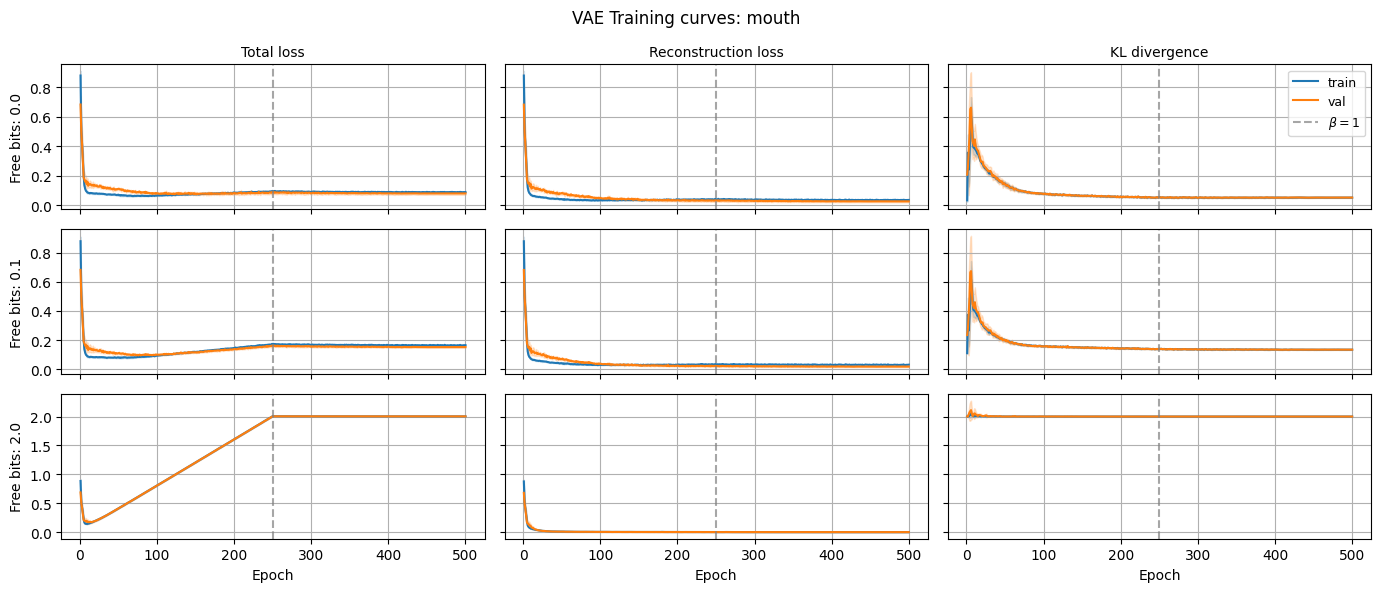

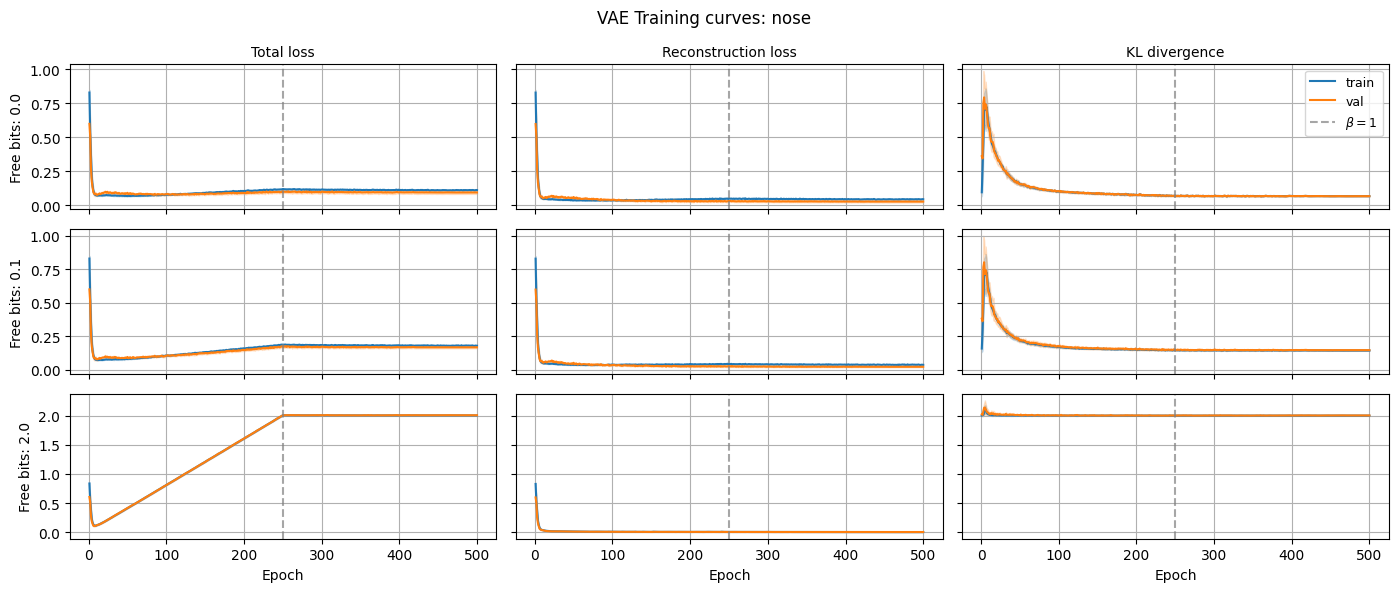

In [5]:
# training curves
pairs = [('train_loss', 'val_loss', 'Total loss'),
         ('train_recon', 'val_recon', 'Reconstruction loss'),
         ('train_kl', 'val_kl', 'KL divergence')]

for region in REGIONS:
    n_configs = len(FREE_BITS)
    fig, axes = plt.subplots(n_configs, 3, figsize=(14, 6), sharey='row', sharex=True)
    fig.suptitle(f'VAE Training curves: {region}')

    for row, free_bit in enumerate(FREE_BITS):
        hists = [pd.read_csv(f'results/experiments/vae/{region}_s{seed}_fb{free_bit}_train_history.csv') for seed in SEEDS]
        epochs = hists[0]['epoch'].values
        beta_one_median = int(np.median([h.loc[h['beta'] >= 1.0, 'epoch'].min() for h in hists]))

        for col, (tr_col, vl_col, title) in enumerate(pairs):
            ax = axes[row, col]
            for data_col, label, color in [(tr_col, 'train', 'tab:blue'), (vl_col, 'val', 'tab:orange')]:
                vals = np.stack([h[data_col].values for h in hists])
                mean = vals.mean(axis=0)
                std  = vals.std(axis=0)
                ax.plot(epochs, mean, label=label, color=color)
                ax.fill_between(epochs, mean - std, mean + std, alpha=0.2, color=color)
            ax.axvline(beta_one_median, color='gray', linestyle='--', alpha=0.7, label=r'$\beta=1$')
            if row == 0:
                ax.set_title(title)
            if col == 0:
                ax.set_ylabel(f'Free bits: {free_bit}')
            if row == n_configs - 1:
                ax.set_xlabel('Epoch')
            ax.legend(loc='upper right') if (row, col) == (0, 2) else None
            ax.grid()

    plt.tight_layout()
    plt.show()

Stable training curves do not preclude posterior collapse at the dimension level. We inspect the mean KL contribution per latent dimension across the training set to determine how many dimensions carry information beyond the prior.

For fb=0.0 and fb=0.1, only 2–4 dimensions exceed the 0.1 nats threshold; the remaining dimensions collapse to the prior (KL ≈ 0). For fb=2.0, all 32 dimensions are active, but each is clamped near the floor value — the encoder distributes KL uniformly rather than concentrating it in discriminative directions. In both failure modes, the latent space lacks the structure needed for class-conditional generation.

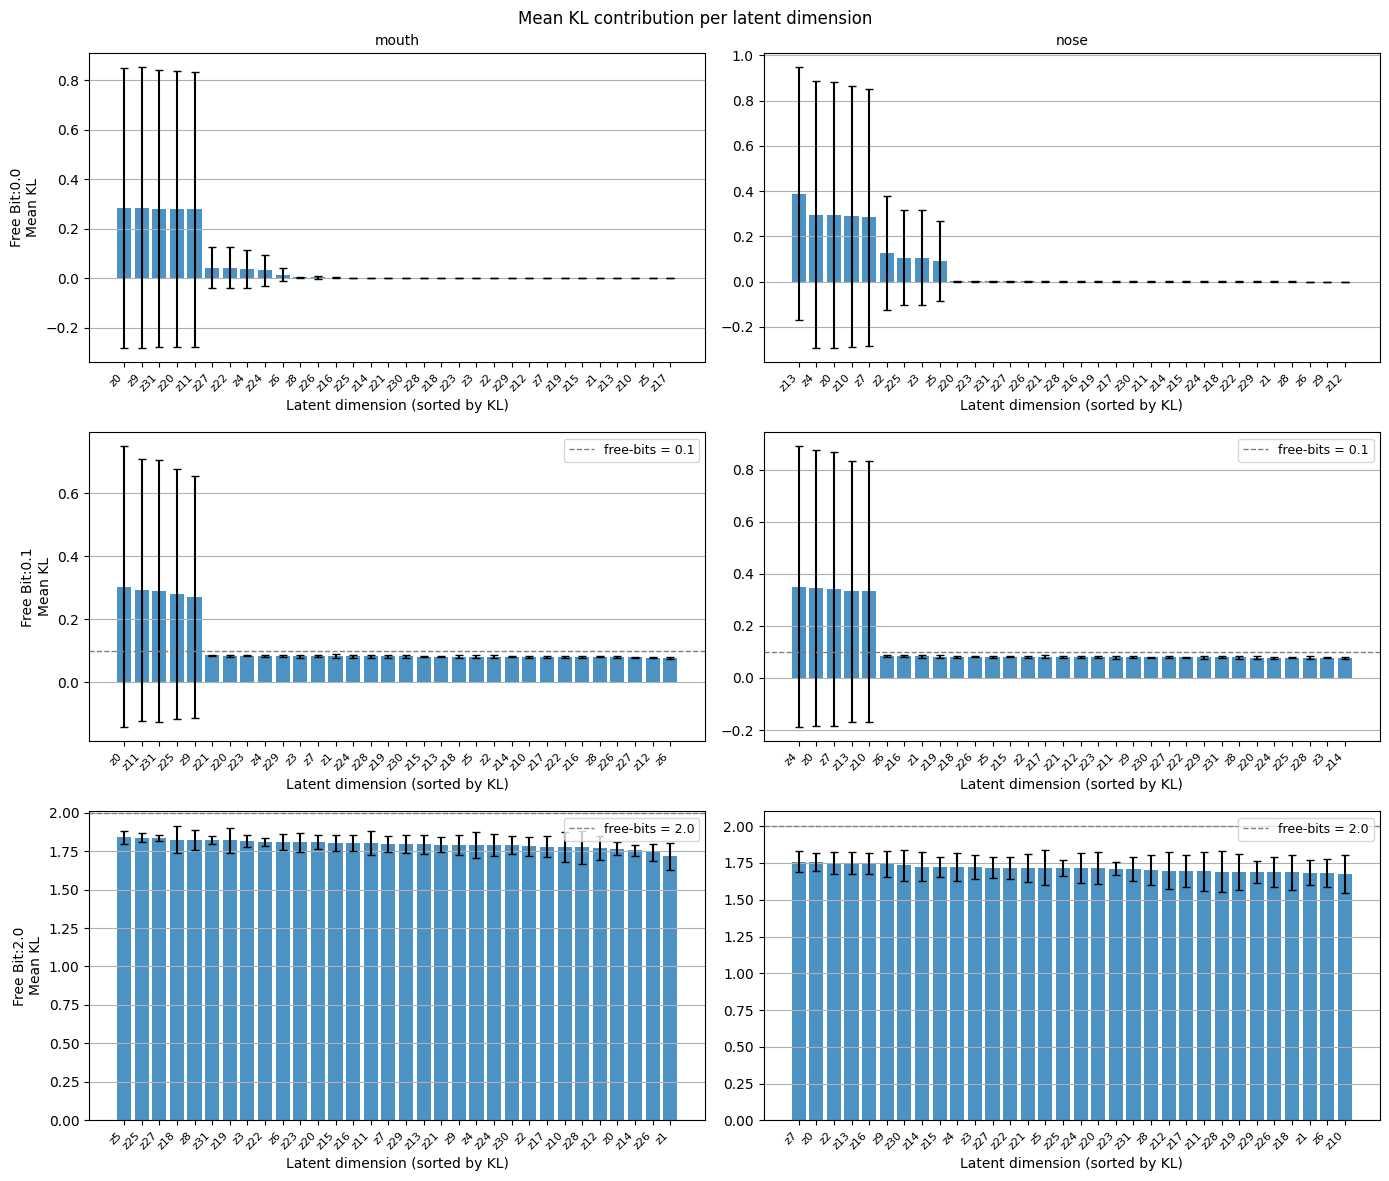

In [6]:
# plot latent dimension activation
n_configs = len(FREE_BITS)
fig, axes = plt.subplots(n_configs, 2, figsize=(14, 4 * n_configs))
fig.suptitle('Mean KL contribution per latent dimension')

for row, free_bit in enumerate(FREE_BITS):
    for col, region in enumerate(REGIONS):
        ax = axes[row, col]
        kl_per_dim_seeds = []

        for seed in SEEDS:
            train_ds = datasets[seed][region]['train']
            model = models[seed][region][free_bit]
            model.eval()

            mus, logvars = [], []
            with torch.no_grad():
                for i in range(len(train_ds)):
                    signal, _, _ = train_ds[i]
                    mu, logvar = model.encoder(signal.unsqueeze(0).to(device))
                    mus.append(mu.squeeze(0).cpu())
                    logvars.append(logvar.squeeze(0).cpu())

            mus     = torch.stack(mus)
            logvars = torch.stack(logvars)
            kl_per_dim = (-0.5 * (1 + logvars - mus.pow(2) - logvars.exp())).mean(dim=0)
            kl_per_dim_seeds.append(kl_per_dim.numpy())

        kl_mean = np.mean(kl_per_dim_seeds, axis=0)
        kl_std = np.std(kl_per_dim_seeds,  axis=0)
        order = np.argsort(kl_mean)[::-1]
        x = np.arange(len(kl_mean))

        ax.bar(x, kl_mean[order], yerr=kl_std[order], capsize=3, color='tab:blue', alpha=0.8)
        if free_bit > 0:
            ax.axhline(free_bit, color='gray', linestyle='--', linewidth=1, label=f'free-bits = {free_bit}')
            ax.legend()
        ax.set_xticks(x)
        ax.set_xticklabels([f'z{i}' for i in order], rotation=45, ha='right', fontsize=8)
        ax.set_xlabel('Latent dimension (sorted by KL)')
        if row == 0:
            ax.set_title(region)
        if col == 0:
            ax.set_ylabel(f'Free Bit:{free_bit}\nMean KL')
        ax.grid(axis='y')

plt.tight_layout()
plt.show()

The per-dimension KL plot shows the final state. To understand when and how collapse occurs, we track the number of active dimensions (KL > 0.1) across training epochs.

Collapse is rapid and irreversible: fb=0.0 and fb=0.1 drop from 32 active dimensions to fewer than 3 within the first 100 epochs and remain there. Notably, fb=0.1 collapses faster and more completely than fb=0.0, demonstrating that a mild KL floor does not prevent collapse and can accelerate it. Only fb=2.0 maintains full dimensionality, but as shown below, this does not translate to useful generation.

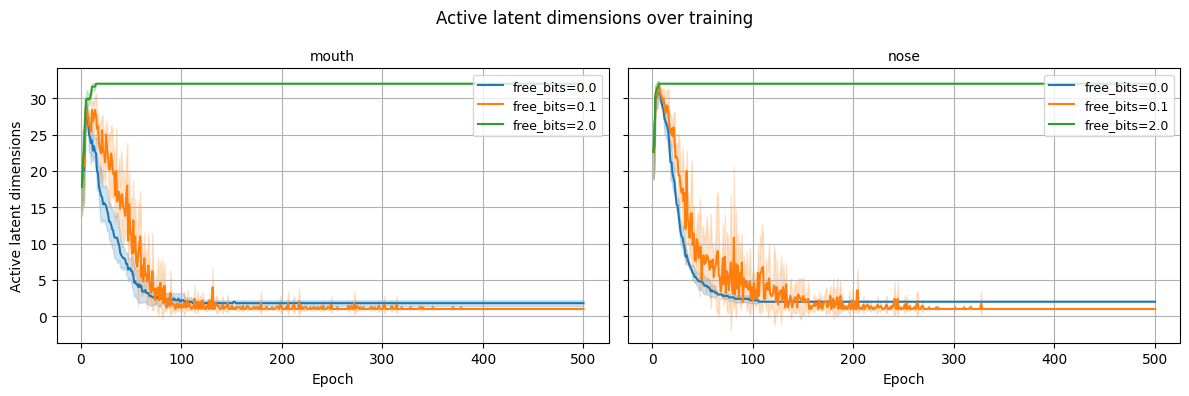

In [7]:
# active dims in training
FB_COLORS = {0.0: 'tab:blue', 0.1: 'tab:orange', 2.0: 'tab:green'}
KL_THRESHOLD = 0.1

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
fig.suptitle('Active latent dimensions over training')

for col, region in enumerate(REGIONS):
    ax = axes[col]
    for free_bit in FREE_BITS:
        hists = [pd.read_csv(f'results/experiments/vae/{region}_s{seed}_fb{free_bit}_train_history.csv') for seed in SEEDS]
        epochs = hists[0]['epoch'].values
        active = np.stack([h['active_dims'].values for h in hists])
        mean = active.mean(axis=0)
        std  = active.std(axis=0)
        color = FB_COLORS[free_bit]
        ax.plot(epochs, mean, label=f'free_bits={free_bit}', color=color)
        ax.fill_between(epochs, mean - std, mean + std, alpha=0.2, color=color)
    ax.set_title(region)
    ax.set_xlabel('Epoch')
    if col == 0:
        ax.set_ylabel('Active latent dimensions')
    ax.legend(loc='upper right')
    ax.grid()

plt.tight_layout()
plt.show()

We project the encoder means onto two dimensions using t-SNE to examine whether the latent space organizes samples by class. A well-structured generative model should show class-separated clusters. A collapsed model should show class-mixed geometry.

Across all three configurations, class labels are mixed within every visible cluster. The apparent groupings reflect signal magnitude or participant identity rather than breathing pattern class. This confirms that the latent space encodes no class-discriminative structure regardless of the free bits setting, explaining the near-chance TSTR performance observed across all VAE configurations.

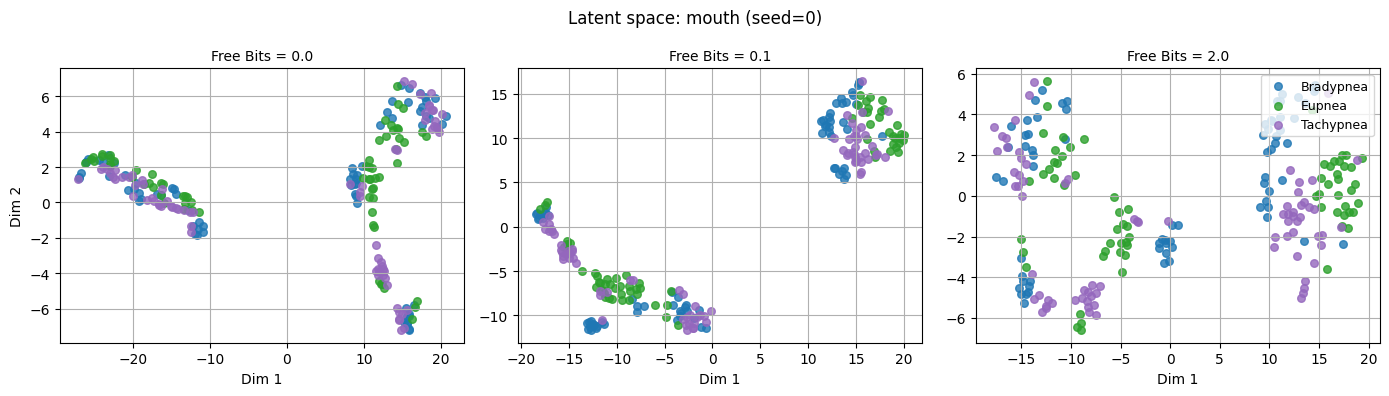

In [8]:
seed = SEEDS[0]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'Latent space: mouth (seed={seed})')

for col, free_bit in enumerate(FREE_BITS):
    ax = axes[col]
    train_ds = datasets[seed]['mouth']['train']
    model = models[seed]['mouth'][free_bit]
    model.eval()
    mus, labels = [], []
    with torch.no_grad():
        for i in range(len(train_ds)):
            signal, _, label = train_ds[i]
            mu, _ = model.encoder(signal.unsqueeze(0).to(device))
            mus.append(mu.squeeze(0).cpu().numpy())
            labels.append(label)
    mus    = np.stack(mus)
    labels = np.array(labels)
    z2d = TSNE(n_components=2, random_state=seed).fit_transform(mus)
    for i, cls in enumerate(CLASSES):
        mask = labels == i
        points = z2d[mask]
        ax.scatter(points[:, 0], points[:, 1], label=cls.capitalize(), alpha=0.8, color=CLASS_COLORS[cls], s=30)
    ax.set_title(f'Free Bits = {free_bit}')
    ax.set_xlabel('Dim 1')
    if col == 0:
        ax.set_ylabel('Dim 2')
    ax.legend(loc='upper right') if col == 2 else None
    ax.grid()
plt.tight_layout()
plt.show()

TSTR accuracy measures classifier performance but does not directly characterize generation quality. We measure pairwise cosine similarity among generated samples as a proxy for diversity: a similarity of 1.0 indicates all samples are identical, lower values indicate more varied generation.

Sample diversity increases monotonically with free bits (mouth: 0.665 → 0.705 → 0.914), confirming that the regularization knob meaningfully affects generation variety. However, TSTR accuracy remains near chance across all configurations, the key decoupling result. Diversity is necessary but not sufficient: without class conditioning, the latent space cannot direct generation toward specific breathing patterns, and a downstream classifier trained on the resulting samples learns nothing transferable to real data. This motivates the conditional architecture introduced in the next section.

In [9]:
# cosine similarity of samples
@torch.no_grad()
def mean_cosine_sim(model, n=100):
    samples = model.sample(n, device).cpu().numpy()
    flat = samples.reshape(n, -1)
    normed = normalize(flat)
    sim = normed @ normed.T
    mask = ~np.eye(n, dtype=bool)
    return float(sim[mask].mean())

rows = []
for free_bit in FREE_BITS:
    for region in REGIONS:
        sims = [mean_cosine_sim(models[seed][region][free_bit]) for seed in SEEDS]
        rows.append({'free_bits': free_bit,
                     'region': region,
                     'cosine_sim_mean': round(np.mean(sims), 4),
                     'cosine_sim_std': round(np.std(sims),  4),
                     'formatted': f"{np.mean(sims):.4f} ± {np.std(sims):.4f}"})

df_cos = pd.DataFrame(rows)
print(df_cos[['free_bits', 'region', 'formatted']].to_string(index=False))

 free_bits region       formatted
       0.0  mouth 0.6666 ± 0.0244
       0.0   nose 0.5575 ± 0.0238
       0.1  mouth 0.7183 ± 0.0146
       0.1   nose 0.5784 ± 0.0236
       2.0  mouth 0.9147 ± 0.0067
       2.0   nose 0.8446 ± 0.0166


## CVAE

The VAE diagnostic established that unconditional generation fails regardless of regularization strategy: without class conditioning, the latent space encodes no class-discriminative structure and TSTR remains near chance. We now evaluate the Conditional VAE (CVAE), which receives the class label as input to both encoder and decoder, offloading class identity from the latent space and allowing it to model within-class variation instead.

The CVAE achieves 0.793 ± 0.116 accuracy on mouth and 0.579 ± 0.037 on nose, substantially above chance (0.333) and well above the unconditional VAE (0.471 mouth). The higher variance on mouth (±0.116 vs ±0.037 nose) is attributable to sample-level variation across seeds rather than training instability, per-seed analysis confirms that two seeds (0 and 1) produce harder test splits, pulling the mean down. The conditioning mechanism is working: class information is successfully transferred to the synthetic data.

In [10]:
# load vae models
models = {seed: {region: {} for region in REGIONS} for seed in SEEDS}
datasets = {seed: {} for seed in SEEDS}
splits = {seed: {} for seed in SEEDS}

for seed in SEEDS:
    for region in REGIONS:
        df = load_dataset()
        df = df[df["region"] == region].reset_index(drop=True)
        df_train, df_val, df_test = split_dataset(df, random_state=seed)
        train_ds = BreathDataset(df_train)
        datasets[seed][region] = {"train": train_ds,
                                  "val":   BreathDataset(df_val,  stats=train_ds.stats),
                                  "test":  BreathDataset(df_test, stats=train_ds.stats)}
        splits[seed][region] = {"train": df_train, "val": df_val, "test": df_test}

        ckpt_path = f'results/experiments/cvae/{region}_s{seed}_fb0.0_checkpoint.pt'
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        model = CVAE(latent_dim=ckpt['latent_dim'], embed_dim=ckpt['embed_dim']).to(device)
        model.load_state_dict(ckpt['model_state'])
        model.eval()
        models[seed][region] = model

# accuracy summary 
rows = []
for region in REGIONS:
    accs = []
    for seed in SEEDS:
        path = f'results/experiments/cvae/{region}_s{seed}_fb0.0_tstr.json'
        with open(path) as f:
            accs.append(json.load(f)['metrics']['accuracy'])
    rows.append({'free_bits': free_bit,
                    'region': region,
                    'mean': round(np.mean(accs), 4),
                    'std': round(np.std(accs),  4),
                    'formatted': f"{np.mean(accs):.4f} ± {np.std(accs):.4f}"})

df_acc = pd.DataFrame(rows)
print(df_acc[['region', 'formatted']].to_string(index=False))

region       formatted
 mouth 0.7929 ± 0.1161
  nose 0.5789 ± 0.0372


We examine the CVAE training curves to verify that conditioning does not destabilize the beta-VAE objective. Unlike the unconditional VAE, the CVAE receives the label embedding at each forward pass, so the encoder only needs to capture residual within-class variation in the latent space.

Training is stable across all seeds: reconstruction loss decreases monotonically, KL divergence peaks during annealing then stabilizes, and train/val curves remain close throughout. Notably, the KL settles at a higher value than in the unconditional VAE, a consequence of the latent space remaining active rather than collapsing, as the conditioning signal handles class identity and the encoder is free to use its capacity for within-class variation.

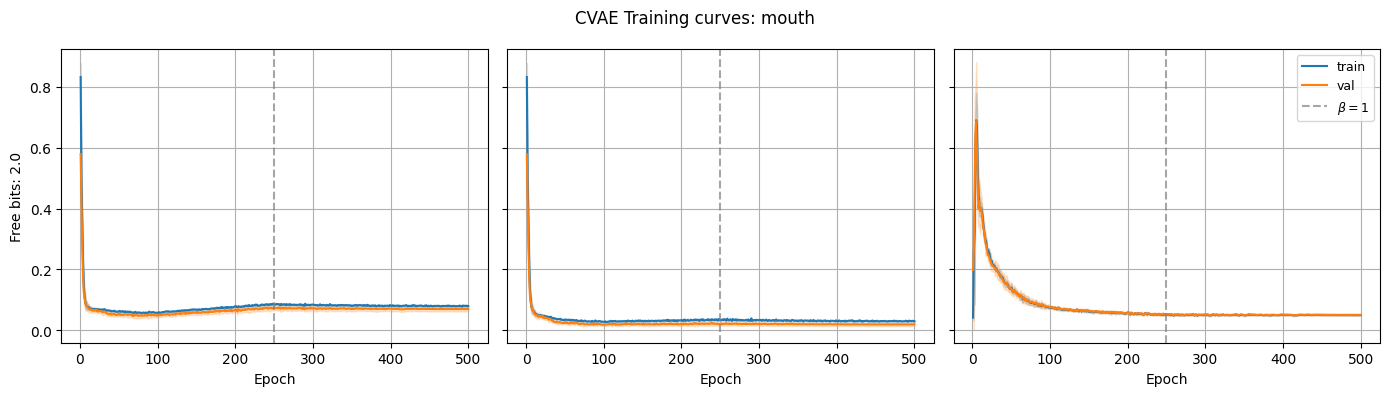

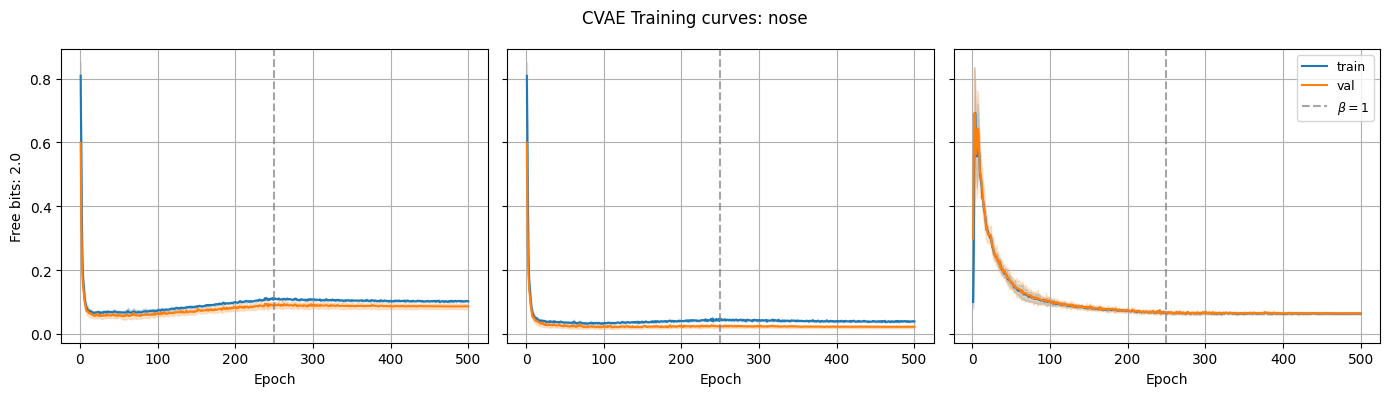

In [11]:
# training curves
pairs = [('train_loss', 'val_loss', 'Total loss'),
         ('train_recon', 'val_recon', 'Reconstruction loss'),
         ('train_kl', 'val_kl', 'KL divergence')]

for region in REGIONS:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey='row', sharex=True)
    fig.suptitle(f'CVAE Training curves: {region}')

    hists = [pd.read_csv(f'results/experiments/cvae/{region}_s{seed}_fb0.0_train_history.csv') for seed in SEEDS]
    epochs = hists[0]['epoch'].values
    beta_one_median = int(np.median([h.loc[h['beta'] >= 1.0, 'epoch'].min() for h in hists]))

    for col, (tr_col, vl_col, title) in enumerate(pairs):
        ax = axes[col]
        for data_col, label, color in [(tr_col, 'train', 'tab:blue'), (vl_col, 'val', 'tab:orange')]:
            vals = np.stack([h[data_col].values for h in hists])
            mean = vals.mean(axis=0)
            std  = vals.std(axis=0)
            ax.plot(epochs, mean, label=label, color=color)
            ax.fill_between(epochs, mean - std, mean + std, alpha=0.2, color=color)
        ax.axvline(beta_one_median, color='gray', linestyle='--', alpha=0.7, label=r'$\beta=1$')
        if col == 0:
            ax.set_ylabel(f'Free bits: {free_bit}')
        ax.set_xlabel('Epoch')
        ax.legend(loc='upper right') if col == 2 else None
        ax.grid()

    plt.tight_layout()
    plt.show()

We project the CVAE encoder means using t-SNE to examine whether conditioning produces a qualitatively different latent geometry compared to the VAE. Since the class label is provided explicitly, the latent space should reflect within-class variation rather than class-discriminative structure.

The CVAE latent space shows partial class clustering, classes are more separated than in any of the VAE configurations, though overlap remains. This is the expected behavior: the conditioning resolves the class-separation problem, but within-class variation (participant identity, signal amplitude) still produces overlapping distributions. The residual overlap is consistent with the 0.159 accuracy gap to TRTR and reflects the domain shift between synthetic and real data rather than a failure of the conditioning mechanism.

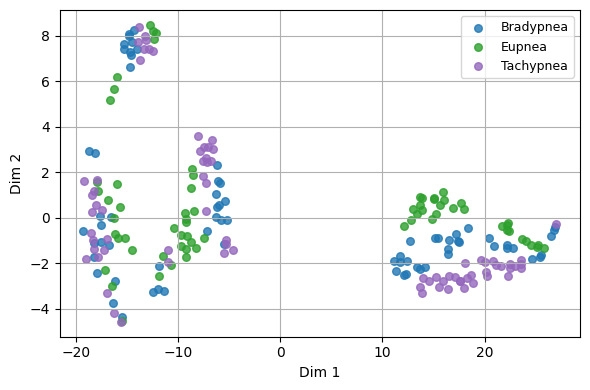

In [12]:
seed = SEEDS[0]
plt.figure(figsize=(6, 4))
train_ds = datasets[seed]['mouth']['train']
model = models[seed]['mouth']
model.eval()

mus, labels = [], []
with torch.no_grad():
    for i in range(len(train_ds)):
        signal, _, label = train_ds[i]
        mu, _ = model.encoder(signal.unsqueeze(0).to(device),
                            torch.tensor([label]).long().to(device))
        mus.append(mu.squeeze(0).cpu().numpy())
        labels.append(label)

mus = np.stack(mus)
labels = np.array(labels)
z2d = TSNE(n_components=2, random_state=seed).fit_transform(mus)
for i, cls in enumerate(CLASSES):
    mask = labels == i
    points = z2d[mask]
    plt.scatter(points[:, 0], points[:, 1], label=cls.capitalize(), alpha=0.8, color=CLASS_COLORS[cls], s=30)
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.legend(loc='upper right') if col == 2 else None
plt.grid()
plt.tight_layout()
plt.show()

We inspect generated samples per class to assess whether the CVAE produces physically plausible breath signals with the correct class-discriminative transient dynamics. Five samples per class are drawn from the prior and decoded with the corresponding class label.

Generated samples exhibit the expected class-discriminative transient structure: bradypnea shows a slow rise reaching saturation late in the window, eupnea a moderate rise, and tachypnea a steep early rise consistent with faster breathing cycles. Within-class variation across the five samples is visible and plausible. The humidity channel shows cleaner class separation than temperature, consistent with the sensor characteristics established in the dataset analysis. The residual TSTR gap to TRTR (0.159 mouth) is attributable to domain shift between synthetic and real samples rather than a failure to capture class structure, the generated signals are visually faithful to the real data distribution.

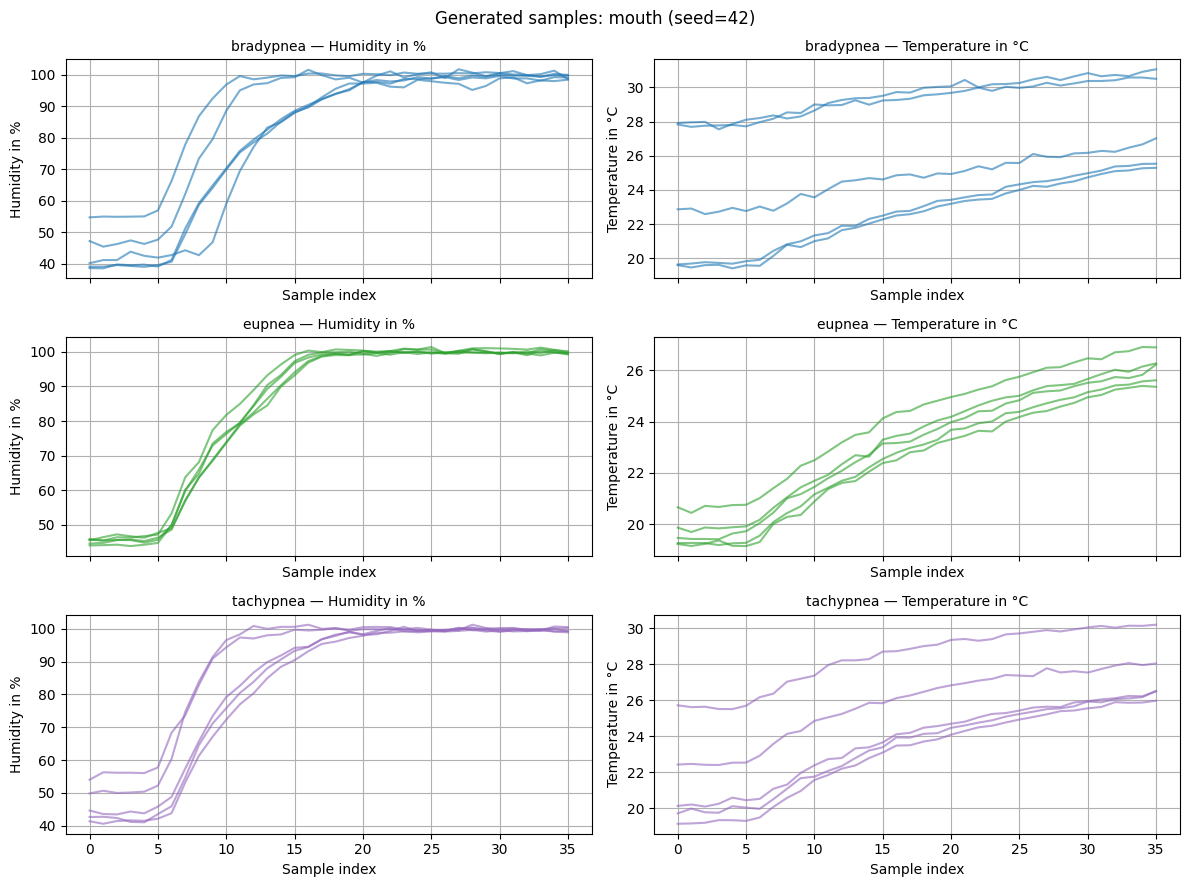

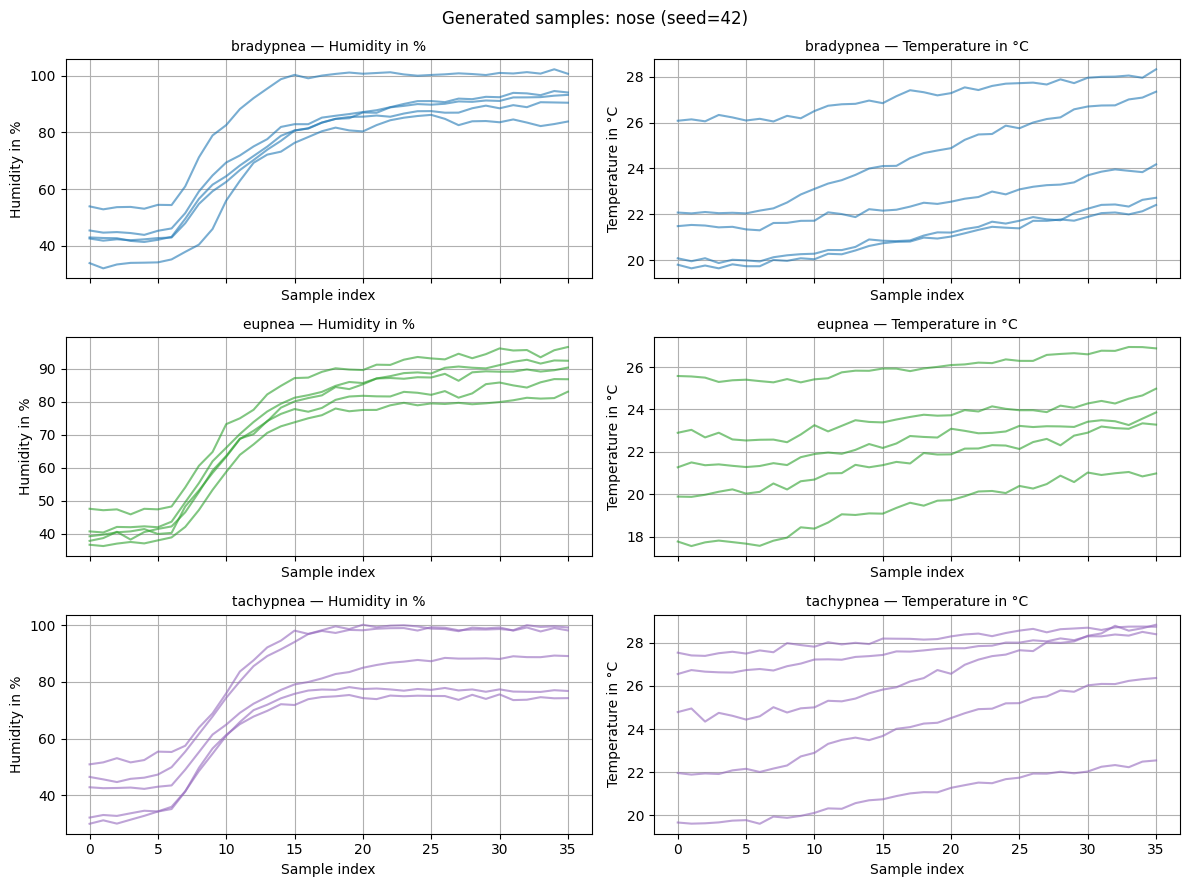

In [13]:
N_SAMPLES = 5
SEED_PLOT = 42

for region in REGIONS:
    ckpt = torch.load(f'results/experiments/cvae/{region}_s{SEED_PLOT}_fb0.0_checkpoint.pt',
                      map_location=device, weights_only=False)
    cvae = CVAE(latent_dim=ckpt['latent_dim'], embed_dim=ckpt['embed_dim']).to(device)
    cvae.load_state_dict(ckpt['model_state'])
    cvae.eval()
    mean = ckpt['stats']['mean']
    std = ckpt['stats']['std']

    fig, axes = plt.subplots(len(CLASSES), 2, figsize=(12, 3 * len(CLASSES)), sharex=True)
    fig.suptitle(f'Generated samples: {region} (seed={SEED_PLOT})')

    for row, cls in enumerate(CLASSES):
        cls_idx = row
        y = torch.full((N_SAMPLES,), cls_idx, dtype=torch.long, device=device)
        with torch.no_grad():
            samples = cvae.sample(N_SAMPLES, y, device).cpu().numpy()
        samples[:, 0, :] = samples[:, 0, :] * std[0] + mean[0]
        samples[:, 1, :] = samples[:, 1, :] * std[1] + mean[1]

        for ch, (ch_name, ax) in enumerate(zip(CHANNEL_NAMES, axes[row])):
            for i in range(N_SAMPLES):
                ax.plot(samples[i, ch, :], alpha=0.6, color=CLASS_COLORS[cls])
            ax.set_title(f'{cls} — {ch_name}')
            ax.set_xlabel('Sample index')
            ax.set_ylabel(ch_name)
            ax.grid()

    plt.tight_layout()
    plt.show()


## GAN

We evaluate a conditional GAN (CGAN) as a second conditional baseline. Unlike the CVAE, the GAN has no explicit latent space structure or reconstruction objective, the generator learns to produce samples that fool the discriminator, conditioned on the class label. This provides a direct comparison between likelihood-based (CVAE) and adversarial (GAN) conditional generation.

In [14]:
# accuracy summary 
rows = []
for region in REGIONS:
    accs = []
    for seed in SEEDS:
        path = f'results/experiments/gan/{region}_s{seed}_tstr.json'
        with open(path) as f:
            accs.append(json.load(f)['metrics']['accuracy'])
    rows.append({'free_bits': free_bit,
                    'region': region,
                    'mean': round(np.mean(accs), 4),
                    'std': round(np.std(accs),  4),
                    'formatted': f"{np.mean(accs):.4f} ± {np.std(accs):.4f}"})

df_acc = pd.DataFrame(rows)
print(df_acc[['region', 'formatted']].to_string(index=False))

region       formatted
 mouth 0.4286 ± 0.1010
  nose 0.3947 ± 0.0686


The training curves reveal characteristic GAN instability. The discriminator loss stabilizes near zero after ~50 epochs, indicating it successfully distinguishes real from generated samples throughout training. The generator loss oscillates with high variance and no convergence trend, with excursions exceeding ±40, a signature of the generator and discriminator failing to reach a stable equilibrium. The occasional discriminator spikes correspond to episodes where the generator temporarily produces more convincing samples before the discriminator recovers. This instability is consistent across seeds, as shown by the wide confidence bands on the generator loss.

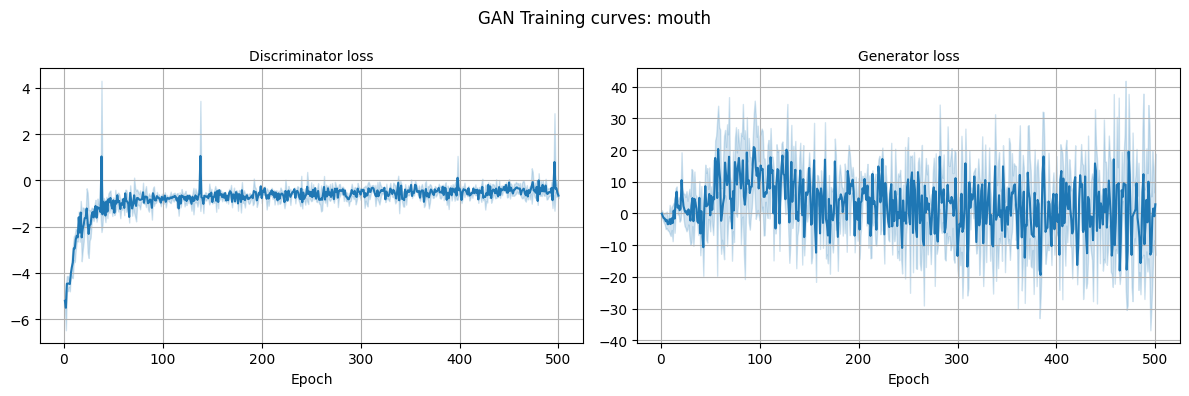

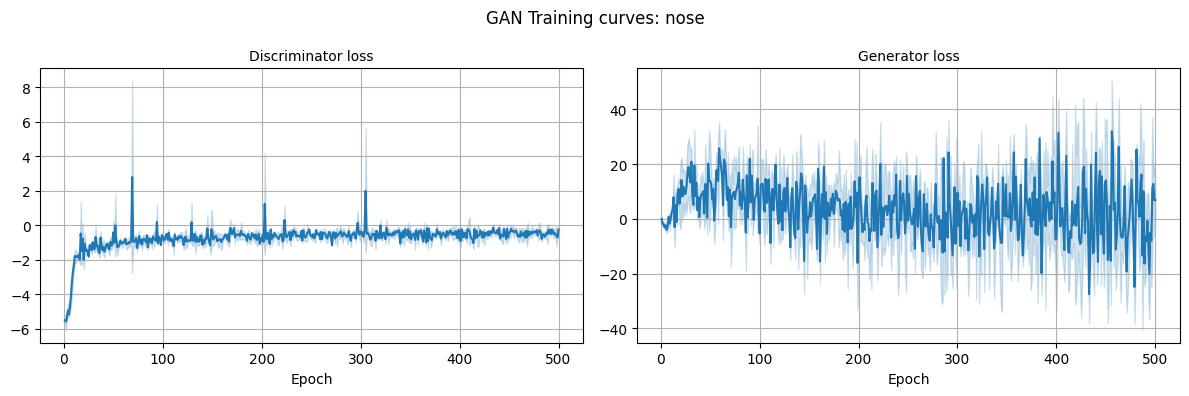

In [15]:
# training curves
GAN_SEEDS = [7, 42, 123]

for region in REGIONS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
    fig.suptitle(f'GAN Training curves: {region}')

    hists = [pd.read_csv(f'results/experiments/gan/{region}_s{seed}_train_history.csv') for seed in GAN_SEEDS]
    epochs = hists[0]['epoch'].values

    for col, (col_name, title) in enumerate([('d_loss', 'Discriminator loss'), ('g_loss', 'Generator loss')]):
        ax = axes[col]
        vals = np.stack([h[col_name].values for h in hists])
        mean = vals.mean(axis=0)
        std  = vals.std(axis=0)
        ax.plot(epochs, mean, color='tab:blue')
        ax.fill_between(epochs, mean - std, mean + std, alpha=0.2, color='tab:blue')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.grid()

    plt.tight_layout()
    plt.show()

In [16]:
# cosine similarity
@torch.no_grad()
def mean_cosine_sim_cgan(model, region, n=100):
    samples_list = []
    per_class = n // 3
    for cls_idx in range(3):
        y = torch.full((per_class,), cls_idx, dtype=torch.long, device=device)
        s = model.sample(per_class, y, device).cpu().numpy()
        samples_list.append(s)
    samples = np.concatenate(samples_list, axis=0)
    flat = samples.reshape(len(samples), -1)
    normed = normalize(flat)
    sim = normed @ normed.T
    mask = ~np.eye(len(samples), dtype=bool)
    return float(sim[mask].mean())

rows = []
for region in REGIONS:
    sims = []
    for seed in GAN_SEEDS:
        ckpt = torch.load(f'results/experiments/gan/{region}_s{seed}_checkpoint.pt',
                          map_location=device, weights_only=False)
        gan = CGAN(latent_dim=ckpt['latent_dim'], embed_dim=ckpt['embed_dim']).to(device)
        gan.load_state_dict(ckpt['model_state'])
        gan.eval()
        sims.append(mean_cosine_sim_cgan(gan, region))
    rows.append({'region': region,
                 'cosine_sim_mean': round(np.mean(sims), 4),
                 'cosine_sim_std':  round(np.std(sims),  4),
                 'formatted': f"{np.mean(sims):.4f} ± {np.std(sims):.4f}"})

df_cos_gan = pd.DataFrame(rows)
print(df_cos_gan[['region', 'formatted']].to_string(index=False))

region       formatted
 mouth 0.6792 ± 0.0219
  nose 0.5384 ± 0.0195


In [18]:
!jupyter nbconvert tstr.ipynb --to pdf --no-input --TagRemovePreprocessor.enabled=True --TagRemovePreprocessor.remove_cell_tags='{"remove_cell"}'

[NbConvertApp] Converting notebook tstr.ipynb to pdf
[NbConvertApp] Support files will be in tstr_files/
[NbConvertApp] Making directory ./tstr_files
[NbConvertApp] Writing 33479 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1210119 bytes to tstr.pdf
